# Interpolation and Fitting

## Interpolation
We have $n$ known dataset $(x_j, y_j)$, with $j=0,1,2,...,n-1$. We want to approximate $y(x)$ for general $x$, using a function $p(x) \equiv \sum_{k=0}^{n-1} c_k \phi_k(x)$, with our own choice of $\phi_k(x)$. 

If we further require that $p(x_j)=y(x_j) \equiv y_j$, i.e. the interpolated function $p(x)$ has to pass through all the original known dataset, then $c_k$ can be obtained by solving a linear equation: $\mathbf{c} = M^{-1}\mathbf{y}$. Here, $\mathbf{c} = (c_0, c_1, ..., c_{n-1})^T$ and $\mathbf{y} = (y_0, y_1, ..., y_{n-1})^T$.

### Monomial Basis
Here, we choose $\phi_k(x) = x^k$. The corresponding matrix $M$ to be inverted assumes the form of a Vandermonde matrix.

**Example:** Interpolate $f(x) = \frac1{1+25x^2}$ in the range $x\in[-1,1]$, using the monomial basis. Consider equi-distant nodes with $n=$ 11 and 101 points.

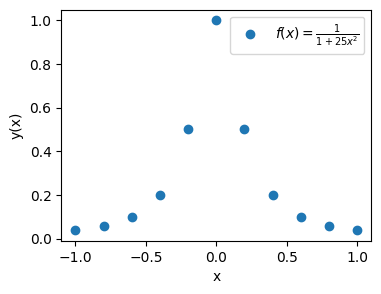

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 1/(1+25*x**2)

n=11
x = np.linspace(-1,1,n)
y = f(x)

# Note about the use of raw string 'r' in front of the LaTeX equation.
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.plot(x,y,'o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

(11, 11)
(11,)


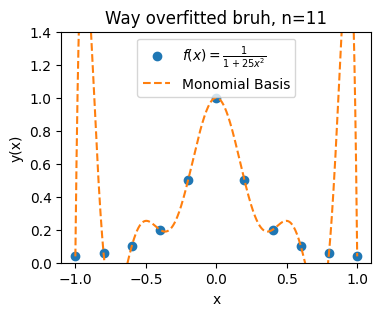

In [2]:
# Construct the corresponding Vandermonde Matrix M:
# Note about the use of Tuple in specifying the matrix dimension:
M = np.zeros((n, n))
print(M.shape)

for ii in range(n):
    M[:,ii] = x**(ii)

y = f(x)
# Linear equation: M c = y
# => c = M^-1 y:
c= np.linalg.solve(M, y)

print(c.shape)

def p(x, c):
    pofx = 0*x # initialize pofx to be the same size as x
    for ii in range(len(c)):
        pofx = pofx + c[ii]*x**ii
    return pofx


nplot = 1001
xinterp = np.linspace(-1,1,nplot)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)

plt.plot(x,y,'o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.plot(xinterp, p(xinterp, c),'--', label='Monomial Basis')

plt.ylim(0,1.4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title(f'Way overfitted bruh, n={n}')
plt.legend()

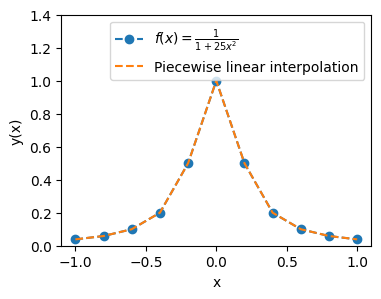

In [3]:
# Note: numpy.interp uses a piecewise linear interpolation,
# which is NOT what we are doing above.
# check the results with n = 11 and n = 101.

nplot = 11
xinterp = np.linspace(-1,1,nplot)
yinterp = np.interp(xinterp, x, y)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)

plt.plot(x,y,'--o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.plot(xinterp, yinterp,'--', label='Piecewise linear interpolation')

plt.ylim(0,1.4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

### Lagrange Interpolation
Here, we choose $\phi_k(x) = L_k(x) \equiv  \frac{\Pi_{j=0,j\ne k}^{n-1}(x- x_j)}{\Pi_{j=0,j\ne k}^{n-1}(x_k - x_j)}$, for $k=0,1,2, ..., n-1$. It is easily seen that $L_k(x_j) = \delta_{kj}$, where $\delta_{kj}$ is the Kronecker delta.

In this case, $c_k = y_k$, and the interpolated function can be obatined directly as $p(x) = \sum_{k=0}^{n-1} y_k L_k(x)$; i.e., there is NO need to solve a linear equation.

**Example:** Fit $f(x) = \frac1{1+25x^2}$ in the range $x\in[-1,1]$, using the Lagrange interpolation. Consider equi-distant nodes with $n=$ 11 and 101 points.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 1/(1+25*x**2)

n=11 # number of data points
x = np.linspace(-1,1,n)
y = f(x) # actual data points

# Define the Lagrange polynomials:
# Note: xinterp, x, and y below are all numpy arrays.
# x and y have a size equal to n (number of the given data points).
# xinterp is the size (called nplot) you want for the final interploated plot.
# nplot and n do NOT need to be the same.

def Lkx(xinterp, x, k): # define Lagrange Polynomials
    n=len(x)
    nplot = len(xinterp)
    Lkx = np.ones(nplot)
    for j in range (n):
        if (j==k): continue
        Lkx = Lkx*(xinterp-x[j])/(x[k]-x[j])
    return Lkx

def p(xinterp, x, y): # interpolated polynomial
    n = len(x)
    nplot = len(xinterp)
    pofx = np.zeros(nplot)
    for k in range(n):
        pofx = pofx + y[k]*Lkx(xinterp, x, k)
    return pofx

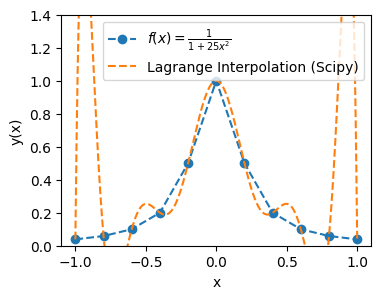

In [12]:
# If we use directly SCIPY functions:
# (you have to "pip install scipy" or "pip3 install scipy" fisrt).
from scipy.interpolate import lagrange

poly = lagrange(x,y)
# The returned object is readily a numpy.poly1d instance;
# it takes an input of numpy array outputs another array of the same size.
yinterp = poly(xinterp)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)

xinterp = np.linspace(-1,1,1001)
plt.plot(x,y,'--o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.plot(xinterp, yinterp,'--', label='Lagrange Interpolation (Scipy)')

plt.ylim(0,1.4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

**Note:** As seen above, polynomial interpolation can be unstable/ill-conditioned when $n$ is too large (e.g. $n\ge 100$). Sigular behaviors can happen in the interpolated function. The interpolation can be improved if we can use Chebyshev nodes $x_j = -\cos(\frac{j\pi}{n-1})$, $j=0,1,2,...$.

Alternatively, we can use **piece-wise interpolation** with a **low-degree polynomial**, as discussed below.

### Cubic-Spline Interpolation
This is a **piece-wise interpolation** with a **3rd-degree polynomial**. For n data points [with (n-1) intervals], there are (4n-4) parameters to be determined. These parameters are constrained by the requirements of (i) continuities of the functions at the given data points [2n-2 conditions] and (ii) continuities of the functions' first and second derivatives at the interior data points [2n-4 conditions], and (iii) the Nature spline condition: second derivaties of the 3rd-degree polynomial is zero at the exterior points [2 contiions].

[[0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.4 0.1 0.  0.  0.  0.  0.
  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.

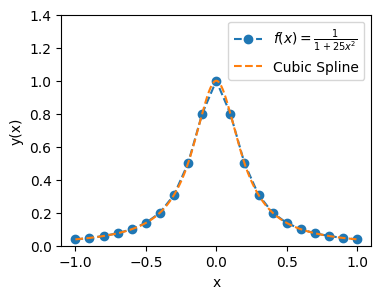

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return 1/(1+25*x**2)

n= 21
x = np.linspace(-1,1,n)
y = f(x)

# Set up the symmetric, tridiagonal matrix M,
# whose dimension is (n-2)x(n-2):
M = np.zeros((n-2,n-2))
M[0,0], M[0,1] = 2*(x[2]-x[0]), (x[2]-x[1]) # first row
M[-1,-2], M[-1,-1] = (x[n-2]-x[n-3]), 2*(x[n-1]-x[n-3]) # last row

# Note about the matrix element definitions:
for k in range(1,n-3):
    M[k,k-1] = x[k+1]-x[k]
    M[k,k]   = 2*(x[k+2]-x[k])
    M[k,k+1] = x[k+2]-x[k+1]
    
#Print out the tridiagonal matrix for check:
print(M)
print(M.shape)

b = np.zeros(n-2)
# Note about the matrix element definitions:
for i in range(n-2):
    k = i + 1 # this method is for k = 1,...,n-2
    b[i] = 6*((y[k+1]-y[k])/(x[k+1]-x[k])-(y[k]-y[k-1])/(x[k]-x[k-1])) # = bk
    # i.e., we want b[i] = bk, where k = 1, 2, ..., n-2

print(b)
print(b.shape)

# Linear equation: M c = b
# => c = M^-1 b:
c = np.linalg.solve(M, b)

# make the coefficient array of size n, with c[0]=0, and c[n-1]=0:
c=np.insert(c, 0, 0.0)
c=np.insert(c, n-1, 0.0)
print('c.shape:', c.shape)
print(c)

#for k=1,2,...,n-1
# here, xi is a single value, not numpy array:
def S(k,xi,x, y):
    s1=y[k-1]*(x[k]-xi)/(x[k]-x[k-1])
    s2=y[k]*(xi-x[k-1])/(x[k]-x[k-1])
    s3=-c[k-1]/6*((x[k]-xi)*(x[k]-x[k-1])-(x[k]-xi)**3/(x[k]-x[k-1]))
    s4=-c[k]/6*((xi-x[k-1])*(x[k]-x[k-1])-(xi-x[k-1])**3/(x[k]-x[k-1]))
    return s1+s2+s3+s4

nplot = 1001
xinterp = np.linspace(-1,1,nplot)
p = np.zeros(len(xinterp))

for ii in range(len(xinterp)):
    k=0
    for jj in range(len(x)):
        if xinterp[ii] >= x[jj-1] and xinterp[ii] <=x[jj]: k = jj 
    p[ii] = S(k, xinterp[ii],x, y)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)

plt.plot(x,y,'--o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.plot(xinterp, p,'--', label='Cubic Spline')

plt.ylim(0,1.4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

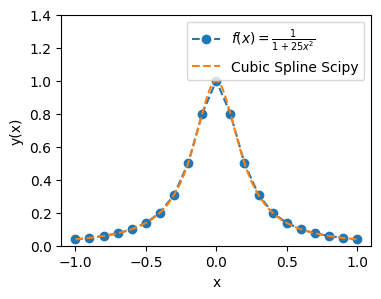

In [17]:
# If we use directly SCIPY functions:
from scipy.interpolate import CubicSpline

cs = CubicSpline(x,y)
# The returned object is readily a scipy.ppoly (piecewise polynomial) instance;
# it takes an input of numpy array outputs another array of the same size.

nplot = 1001
xinterp = np.linspace(-1,1, nplot)
yinterp = cs(xinterp)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)

plt.plot(x,y,'--o', label=r'$f(x)=\frac{1}{1+25x^2}$')
plt.plot(xinterp, yinterp,'--', label='Cubic Spline Scipy')

plt.ylim(0,1.4)
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()

## Least Squares Fitting

Here, we have known dataset $(x_j, y_j)$, with $j=0,1,2, ..., N-1$. We want to fit it with a function $p(x) = \sum_{k=0}^{n-1} c_k \phi_k(x)$. Typically, $n$ is much smaller than $N$.

In least squares fitting, this is achieved by minimizing the least squares error $\chi^2 \equiv \sum_{j=0}^{N-1} (y_j - p(x_j))^2/\sigma_j^2$. Here, $\sigma_j$ is the uncertainty associated with $y_j$. In the resulting fitted function, $p(x_j)$ is not necessarily equal to $y_j$.

### Linear Fitting
As discussed in class, the problem can be analytically solved by matrix inversion in a linear equation. For a linear function $p(x) = c_0 + c_1 x$, we know from our class discussion that $c_0 = (S_{xx}S_y-S_xS_{xy})/\Delta$, and $c_1 = (S S_{xy}-S_xS_y)/\Delta$. Here:

$S\equiv \sum_{j=0}^{N-1} 1/\sigma_j^2$; $S_x\equiv \sum_{j=0}^{N-1} x_j/\sigma_j^2$; $S_y\equiv \sum_{j=0}^{N-1} y_j/\sigma_j^2$; $S_{xx}\equiv \sum_{j=0}^{N-1} x_j^2/\sigma_j^2$; $S_{xy}\equiv \sum_{j=0}^{N-1} x_j y_j/\sigma_j^2$; $\Delta\equiv S S_{xx}-S_x^2$.

**Note:** If no uncertainty is specified, one can simply set $\sigma_j=1$ in the above equation for $\chi^2$.

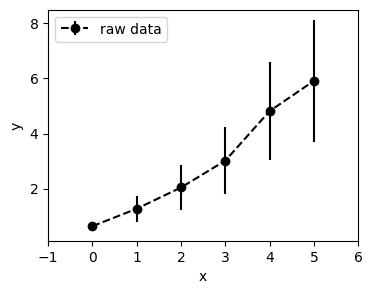

In [26]:
# Create raw data:
N = 6
x = np.linspace(0, 5, N)
rng = np.random.default_rng(seed=0)
epsilon = rng.random(N)
y = x + 1*epsilon
yerr = 0.02+0.2*(x+y)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1,6)
plt.errorbar(x,y, yerr=yerr, c='k', fmt='--o', label='raw data')
plt.legend(loc='upper left')

c0, c1= 0.6162075100110979 0.8539610048271217


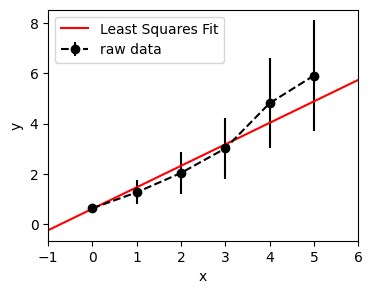

In [27]:
# Linear Least Square Fitting:
S = (1/yerr**2).sum()
Sx = (x/yerr**2).sum()
Sy = (y/yerr**2).sum()
Sxx= (x**2/yerr**2).sum()
Sxy= (x*y/yerr**2).sum()
Delta = S*Sxx-Sx**2

c0 = (Sxx*Sy-Sx*Sxy)/Delta
c1 = (S*Sxy-Sx*Sy)/Delta

print('c0, c1=', c0, c1)

nplot = 101
xinterp = np.linspace(-1,6,nplot)
yinterp = c0*1+c1*xinterp

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1,6)
plt.errorbar(x,y, yerr=yerr, c='k', fmt='--o', label='raw data')
plt.plot(xinterp, yinterp,c='r', label='Least Squares Fit')

plt.legend(loc='upper left')

### General Linear Fitting: Normal Equations

For $p(x)=\sum_{k=0}^{n-1}c_k \phi_k(x)$, the coefficients $\mathbf{c}\equiv (c_0,c_1, ..., c_{n-1})^T$ can be obtained as $\mathbf{c} = (\mathbf{A^T A}^{-1})\mathbf{A^T b}$. Here, the matrix elements are $A_{jk}=\phi_k(x_j)/\sigma_j$, $b_j = y_j/\sigma_j$. $\mathbf{A}$ is an $N\times n$ matrix; $\mathbf{b}$ is an $N\times 1$ vector; $\mathbf{c}$ is an $n\times 1$ vector.

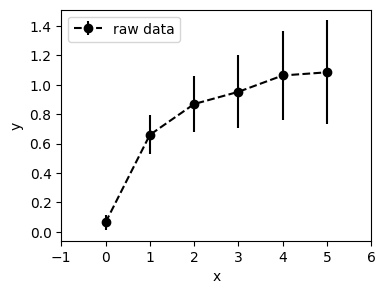

In [28]:
# Create raw data:
N = 6
x = np.linspace(0, 5, N)
rng = np.random.default_rng(seed=0)
epsilon = rng.random(N)
y = (1-np.exp(-x)) + 0.1*epsilon
# example error bar values that vary with x-position
yerr = 0.05+0.05*(x+y)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1,6)
plt.errorbar(x,y, yerr=yerr, c='k', fmt='--o', label='raw data')
plt.legend(loc='upper left')

In [29]:
# Here, we want to fit with p(x) = c0*1+c1*exp(-x), so n=2.
# Construct the A and b matrices:
n=2
A = np.zeros((N,n))
b = np.zeros(N)

def phi(k,xj):
    if k==0: return 1
    if k==1: return np.exp(-xj)

# A:
for j in range(N):
    for k in range(n):
        A[j,k] = phi(k,x[j])/yerr[j]

# b:
for j in range(N):
    b[j] = y[j]/yerr[j]

M1 = np.linalg.inv(np.matmul(np.transpose(A), A))
M2 = np.matmul(np.transpose(A),b)
c = np.matmul(M1,M2)

print('(N,n), (N,), (n,)')
print((N,n), (N,), (n,))
print(A.shape, b.shape, c.shape)

(N,n), (N,), (n,)
(6, 2) (6,) (2,)
(6, 2) (6,) (2,)


**Note:** $\mathbf{c} = (\mathbf{A^T A}^{-1})\mathbf{A^T b}$

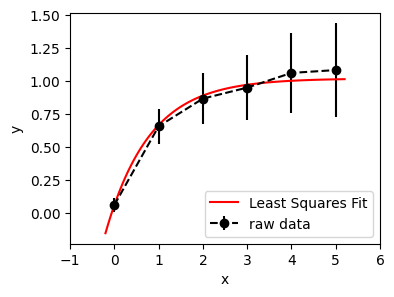

In [30]:
c0=c[0]
c1=c[1]
nplot = 101
xinterp = np.linspace(-0.2,5.2,nplot)
yinterp = c0*1+c1*np.exp(-xinterp)

#plot the results:
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-1,6)
plt.errorbar(x,y, yerr=yerr, c='k', fmt='--o', label='raw data')
plt.plot(xinterp, yinterp,c='r', label='Least Squares Fit')

plt.legend(loc='lower right')